In [1]:
# ==========================================
# STEP 1: Environment Setup & Drive Mounting
# ==========================================

import os
import sys
import torch

print(f"Python Version: {sys.version.split()[0]}")
print(f"PyTorch Version: {torch.__version__}")

# 1. Verify GPU availability and memory
if torch.cuda.is_available():
    device = torch.device("cuda")
    gpu_name = torch.cuda.get_device_name(0)
    total_mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"\n[GPU DETECTED]")
    print(f"Device: {gpu_name}")
    print(f"Dedicated Memory: {total_mem_gb:.2f} GB")
else:
    device = torch.device("cpu")
    print("\n[WARNING] No GPU detected. Running on CPU.")
    print("Go to Runtime -> Change runtime type -> Select T4 GPU if available.")

# 2. Mount Google Drive for persistent checkpoints
try:
    from google.colab import drive
    drive.mount('/content/drive')
    checkpoint_dir = "/content/drive/MyDrive/HatchlingLM/checkpoints"
    os.makedirs(checkpoint_dir, exist_ok=True)
    print(f"\nGoogle Drive mounted successfully.")
    print(f"Checkpoint directory ready: {checkpoint_dir}")
except ImportError:
    # Local fallback if not running on Colab
    checkpoint_dir = "./checkpoints"
    os.makedirs(checkpoint_dir, exist_ok=True)
    print(f"\nNot in Colab. Using local directory: {checkpoint_dir}")

# 3. Install lightweight dependencies
!pip install -q einops tqdm matplotlib

print("\nStep 1 complete! Setup is ready.")

Python Version: 3.13.15
PyTorch Version: 2.11.0+cu128

[GPU DETECTED]
Device: Tesla T4
Dedicated Memory: 14.56 GB
Mounted at /content/drive

Google Drive mounted successfully.
Checkpoint directory ready: /content/drive/MyDrive/HatchlingLM/checkpoints

Step 1 complete! Setup is ready.


In [2]:
# ============================================================
# STEP 2: Dataset Preparation & Byte-Level Tokenization
# ============================================================

import urllib.request
import os
import torch

data_dir = "/content/data"
os.makedirs(data_dir, exist_ok=True)
data_path = os.path.join(data_dir, "tinyshakespeare.txt")

# 1. Download Tiny Shakespeare
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
if not os.path.exists(data_path):
    print("Downloading Tiny Shakespeare corpus...")
    urllib.request.urlretrieve(url, data_path)
    print("Download complete.")
else:
    print("Dataset already exists locally.")

# 2. Inspect raw file
with open(data_path, "rb") as f:
    raw_bytes = f.read()

total_bytes = len(raw_bytes)
print(f"Total raw bytes: {total_bytes:,} ({total_bytes / (1024**2):.2f} MB)")

# 3. Byte-level conversion (0–255 fixed vocabulary)
# Using raw uint8 byte representations directly avoids needing an external tokenizer
tokens = torch.from_numpy(
    __import__("numpy").frombuffer(raw_bytes, dtype=__import__("numpy").uint8).copy()
).long()

# 4. Train / Validation split (90% train, 10% validation)
split_idx = int(0.9 * len(tokens))
train_data = tokens[:split_idx]
val_data = tokens[split_idx:]

print(f"Train set tokens: {len(train_data):,}")
print(f"Val set tokens:   {len(val_data):,}")

# 5. Fast batch loader helper function
def get_batch(split="train", batch_size=16, block_size=128, device="cuda"):
    data = train_data if split == "train" else val_data
    # Pick random starting offsets
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i + block_size] for i in ix])
    y = torch.stack([data[i + 1:i + 1 + block_size] for i in ix])
    return x.to(device), y.to(device)

# 6. Sanity check batch generation
xb, yb = get_batch("train", batch_size=2, block_size=16, device="cpu")
print("\n[Sanity Check Batch Shapes]")
print(f"Input batch shape (X):  {xb.shape}")
print(f"Target batch shape (Y): {yb.shape}")

sample_text = bytes(xb[0].tolist()).decode("utf-8", errors="replace")
print(f"\nSample decoded slice from batch 0:\n{repr(sample_text)}")

Download complete.
Total raw bytes: 1,115,394 (1.06 MB)
Train set tokens: 1,003,854
Val set tokens:   111,540

[Sanity Check Batch Shapes]
Input batch shape (X):  torch.Size([2, 16])
Target batch shape (Y): torch.Size([2, 16])

Sample decoded slice from batch 0:
's more to bread '


In [3]:
# ============================================================
# STEP 3: BDH (Dragon Hatchling) Architecture Implementation
# ============================================================

import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class BDHBlock(nn.Module):
    """
    Core BDH Layer: Sparse non-negative neuron activation
    with biologically inspired synaptic memory update.
    """
    def __init__(self, d_model: int, n_neurons: int, sparsity_thresh: float = 0.05):
        super().__init__()
        self.d_model = d_model
        self.n_neurons = n_neurons
        self.sparsity_thresh = sparsity_thresh

        # Afferent synaptic projection (Input -> High-dim biological neuron pool)
        self.w_in = nn.Linear(d_model, n_neurons, bias=False)

        # Lateral / recurrent synaptic matrix between neurons
        self.w_recurrent = nn.Linear(n_neurons, n_neurons, bias=False)

        # Efferent synaptic projection (Neuron pool -> Output embedding space)
        self.w_out = nn.Linear(n_neurons, d_model, bias=False)

        # Layer normalization for biological homeostasis / stability
        self.ln = nn.LayerNorm(d_model)

    def forward(self, x, return_activations=False):
        """
        x: [B, T, D]
        """
        residual = x
        x_norm = self.ln(x)

        # 1. Project to high-dim neuron space
        pre_act = self.w_in(x_norm) # [B, T, N]

        # 2. Sparse positive activation (Only neurons firing above threshold activate)
        # ReLU ensures non-negative firing rates (strictly biological)
        act = F.relu(pre_act - self.sparsity_thresh)

        # 3. Lateral synaptic integration
        synaptic_signal = self.w_recurrent(act)

        # Combine direct firing rate with synaptic modulation
        total_firing = act + F.relu(synaptic_signal)

        # 4. Project back to embedding dimension
        out = self.w_out(total_firing)
        out = residual + out

        if return_activations:
            return out, act
        return out


class HatchlingLM(nn.Module):
    """
    HatchlingLM: Compact Brain-Inspired Language Model
    """
    def __init__(
        self,
        vocab_size: int = 256,
        d_model: int = 384,
        n_neurons: int = 1536,
        n_layers: int = 6,
        max_seq_len: int = 128,
        sparsity_thresh: float = 0.05
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.max_seq_len = max_seq_len

        # Token and positional embeddings
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_seq_len, d_model)

        # Stacked BDH layers
        self.layers = nn.ModuleList([
            BDHBlock(d_model, n_neurons, sparsity_thresh=sparsity_thresh)
            for _ in range(n_layers)
        ])

        self.final_ln = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

        # Tie input and output weights to save parameters & improve alignment
        self.tok_emb.weight = self.head.weight

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.normal_(p, mean=0.0, std=0.02)

    def forward(self, idx, targets=None, return_activations=False):
        B, T = idx.shape
        assert T <= self.max_seq_len, f"Sequence length {T} exceeds max {self.max_seq_len}"

        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        x = self.tok_emb(idx) + self.pos_emb(pos)

        layer_activations = []
        for layer in self.layers:
            if return_activations:
                x, acts = layer(x, return_activations=True)
                layer_activations.append(acts)
            else:
                x = layer(x)

        x = self.final_ln(x)
        logits = self.head(x) # [B, T, vocab_size]

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, self.vocab_size), targets.view(-1))

        if return_activations:
            return logits, loss, layer_activations
        return logits, loss


# ============================================================
# Model Instantiation & Parameter Verification
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Target: ~15M parameters fitting within Colab T4
model = HatchlingLM(
    vocab_size=256,
    d_model=384,
    n_neurons=1536,
    n_layers=6,
    max_seq_len=128,
    sparsity_thresh=0.05
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"HatchlingLM Model Initialized on: {device}")
print(f"Total Parameters:     {total_params:,} (~{total_params / 1e6:.2f}M)")
print(f"Trainable Parameters: {trainable_params:,}")

# Forward pass sanity check
x_test = torch.randint(0, 256, (2, 64), device=device)
y_test = torch.randint(0, 256, (2, 64), device=device)

logits, loss, acts = model(x_test, targets=y_test, return_activations=True)

# Calculate neuron sparsity (% of neurons that are exactly 0)
zero_acts = (acts[0] == 0.0).float().mean().item() * 100

print("\n[Sanity Check Forward Pass]")
print(f"Logits shape:      {logits.shape}")
print(f"Initial loss:      {loss.item():.4f} (Expected random: ~{-math.log(1/256):.4f})")
print(f"Layer 0 Sparsity:  {zero_acts:.2f}% of neurons are inactive")

HatchlingLM Model Initialized on: cuda
Total Parameters:     21,386,496 (~21.39M)
Trainable Parameters: 21,386,496

[Sanity Check Forward Pass]
Logits shape:      torch.Size([2, 64, 256])
Initial loss:      5.6605 (Expected random: ~5.5452)
Layer 0 Sparsity:  55.07% of neurons are inactive


In [4]:
# ============================================================
# STEP 4: Training Pipeline with Resumable Checkpoints
# ============================================================

import os
import math
import time
import torch
from tqdm.auto import tqdm

# --- Configuration ---
batch_size = 32         # 32 * 128 = 4,096 tokens per step
block_size = 128
max_steps = 2000
eval_interval = 100
save_interval = 250
eval_iters = 30
learning_rate = 6e-4
min_lr = 6e-5
warmup_steps = 150

checkpoint_path = os.path.join(checkpoint_dir, "hatchling_latest.pt")
best_checkpoint_path = os.path.join(checkpoint_dir, "hatchling_best.pt")

# Learning rate schedule (Warmup + Cosine Decay)
def get_lr(step):
    if step < warmup_steps:
        return learning_rate * (step + 1) / warmup_steps
    if step > max_steps:
        return min_lr
    decay_ratio = (step - warmup_steps) / (max_steps - warmup_steps)
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return min_lr + coeff * (learning_rate - min_lr)

# Validation estimator
@torch.no_grad()
def estimate_loss(model, eval_iters):
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            x, y = get_batch(split, batch_size=batch_size, block_size=block_size, device=device)
            with torch.amp.autocast('cuda', dtype=torch.float16):
                _, loss = model(x, targets=y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

# Setup optimizer and GradScaler for mixed precision
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, betas=(0.9, 0.95), weight_decay=0.01)
scaler = torch.amp.GradScaler('cuda')

# Resume checkpoint if available
start_step = 0
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'steps': []}

if os.path.exists(checkpoint_path):
    print(f"Loading checkpoint from: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scaler.load_state_dict(checkpoint['scaler_state_dict'])
    start_step = checkpoint['step'] + 1
    best_val_loss = checkpoint.get('best_val_loss', float('inf'))
    history = checkpoint.get('history', history)
    print(f"Resuming from step {start_step} (Best Val Loss: {best_val_loss:.4f})")
else:
    print("No previous checkpoint found. Starting training from scratch.")

# Training Loop
model.train()
pbar = tqdm(range(start_step, max_steps), desc="Training HatchlingLM")
start_time = time.time()

for step in pbar:
    # Update dynamic learning rate
    lr = get_lr(step)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    # Fetch batch
    xb, yb = get_batch('train', batch_size=batch_size, block_size=block_size, device=device)

    # Forward pass with AMP
    with torch.amp.autocast('cuda', dtype=torch.float16):
        logits, loss = model(xb, targets=yb)

    # Backward pass with scaled gradients
    optimizer.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    scaler.step(optimizer)
    scaler.update()

    # Periodic Evaluation
    if step % eval_interval == 0 or step == max_steps - 1:
        losses = estimate_loss(model, eval_iters)
        val_loss = losses['val']
        train_loss = losses['train']
        history['steps'].append(step)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        pbar.set_postfix({
            'train_loss': f"{train_loss:.3f}",
            'val_loss': f"{val_loss:.3f}",
            'lr': f"{lr:.1e}"
        })

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'step': step,
                'model_state_dict': model.state_dict(),
                'val_loss': best_val_loss,
            }, best_checkpoint_path)

    # Periodic Checkpoint to Drive
    if (step > 0 and step % save_interval == 0) or step == max_steps - 1:
        torch.save({
            'step': step,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
            'best_val_loss': best_val_loss,
            'history': history,
        }, checkpoint_path)

total_duration = time.time() - start_time
print(f"\nTraining complete in {total_duration / 60:.2f} minutes.")
print(f"Best Validation Loss: {best_val_loss:.4f}")
print(f"Checkpoints saved to: {checkpoint_dir}")

No previous checkpoint found. Starting training from scratch.


Training HatchlingLM:   0%|          | 0/2000 [00:00<?, ?it/s]


Training complete in 1.85 minutes.
Best Validation Loss: 2.4802
Checkpoints saved to: /content/drive/MyDrive/HatchlingLM/checkpoints


In [5]:
# ============================================================
# STEP 5: Autoregressive Text Generation & Temperature Sweeps
# ============================================================

import os
import torch
import torch.nn.functional as F

# 1. Load the best checkpoint
best_checkpoint_path = os.path.join(checkpoint_dir, "hatchling_best.pt")
checkpoint = torch.load(best_checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Loaded best checkpoint (Val Loss: {checkpoint.get('val_loss', 'N/A'):.4f})")

# 2. Byte-level Autoregressive Generation Function
@torch.no_grad()
def generate(
    model,
    prompt: str = "ROMEO:\n",
    max_new_tokens: int = 300,
    temperature: float = 0.8,
    top_k: int = 40,
    device: str = "cuda"
):
    model.eval()
    # Encode prompt to UTF-8 byte tensor
    prompt_bytes = list(prompt.encode("utf-8"))
    idx = torch.tensor([prompt_bytes], dtype=torch.long, device=device)

    for _ in range(max_new_tokens):
        # Crop context to model's max sequence length (128)
        idx_cond = idx[:, -128:] if idx.size(1) > 128 else idx

        # Forward pass
        logits, _ = model(idx_cond)
        # Take logits at the final timestep
        logits = logits[:, -1, :] / max(temperature, 1e-5)

        # Optional Top-K filtering
        if top_k is not None:
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = -float('Inf')

        # Sample next token
        probs = F.softmax(logits, dim=-1)
        next_byte = torch.multinomial(probs, num_samples=1)

        idx = torch.cat((idx, next_byte), dim=1)

    generated_bytes = bytes(idx[0].tolist())
    return generated_bytes.decode("utf-8", errors="replace")

# 3. Experiment with different temperatures
prompt = "KING LEAR:\n"
print("=" * 60)
print(f"PROMPT: {repr(prompt)}")
print("=" * 60)

for temp in [0.4, 0.7, 1.0]:
    print(f"\n--- Temperature: {temp} ---")
    output = generate(model, prompt=prompt, max_new_tokens=250, temperature=temp, top_k=50, device=device)
    print(output)
    print("-" * 60)

Loaded best checkpoint (Val Loss: 2.4802)
PROMPT: 'KING LEAR:\n'

--- Temperature: 0.4 ---
KING LEAR:
I te be the thang thig on the at wis the fe thore thitha f wis wan wis sere se ar the this an me the the theresthen te the thethe s the mar there are me the f werer the the te win the t eathe athan be t manger t the t the the me the theathere the ho 
------------------------------------------------------------

--- Temperature: 0.7 ---
KING LEAR:
Fint n d thininoure bond d the
IOLAgand lis athous d g alon ath r's nthard othe oure I nd ofera no thes iorre ando
Thar lethet hanedr theraiso inere beane thorut cis:

S:
Thicay it dyounothise thery tong wie se then f y I whe mewat, tongangrd n te t 
------------------------------------------------------------

--- Temperature: 1.0 ---
KING LEAR:
ANTELORETED aisaughe I'than wothuthan cot POMINTheavetaiselincrird;
Foucis.
Word theerord threm his brond y nou aul pe chopr we.
Bof. RD II o I misthe!
All f ongrithat athierm.
IUKEdanggray n fondrere

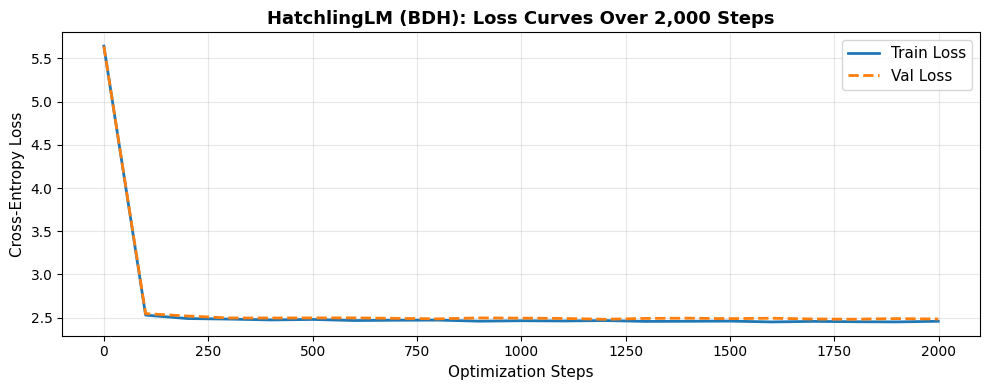

ANALYSIS SAMPLE: 'To be, or not to be, that is the questio'...
Sequence length: 84 tokens (bytes)
Layer 01 | Sparsity: 82.47% | Active Neurons per Byte: 269.3 / 1536
Layer 02 | Sparsity: 84.17% | Active Neurons per Byte: 243.2 / 1536
Layer 03 | Sparsity: 84.86% | Active Neurons per Byte: 232.6 / 1536
Layer 04 | Sparsity: 86.52% | Active Neurons per Byte: 207.0 / 1536
Layer 05 | Sparsity: 89.54% | Active Neurons per Byte: 160.6 / 1536
Layer 06 | Sparsity: 88.64% | Active Neurons per Byte: 174.6 / 1536


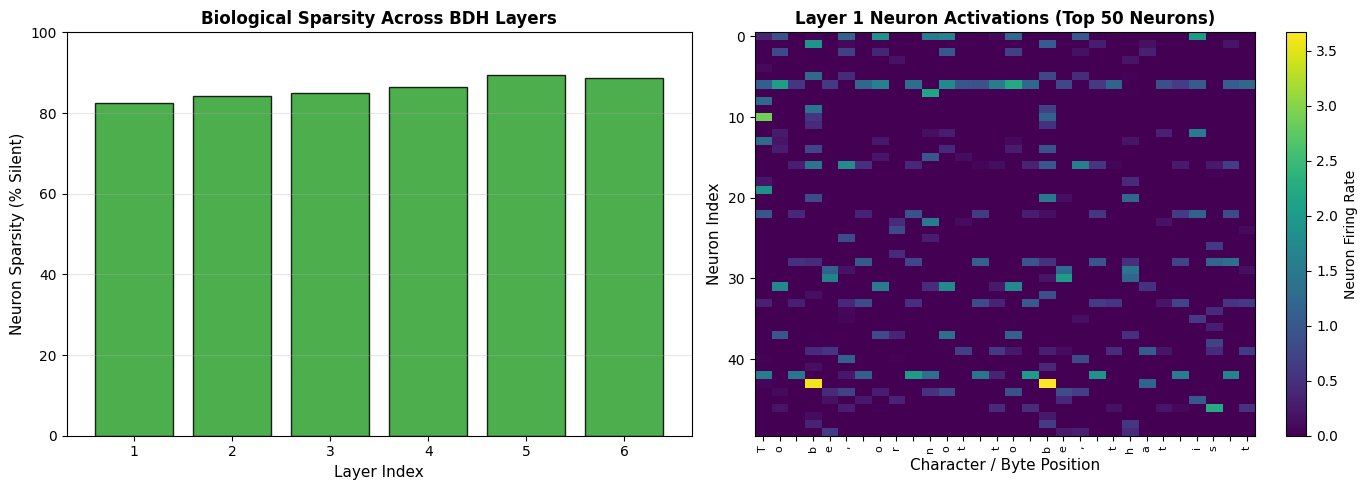

In [6]:
# ============================================================
# STEP 6: Biological Neuron Activation & Sparsity Analysis
# ============================================================

import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Load logged training history
checkpoint_path = os.path.join(checkpoint_dir, "hatchling_latest.pt")
checkpoint = torch.load(checkpoint_path, map_location=device)
history = checkpoint.get("history", None)

# 2. Plot Training & Validation Loss
if history and len(history.get("steps", [])) > 0:
    plt.figure(figsize=(10, 4))
    plt.plot(history['steps'], history['train_loss'], label="Train Loss", color="#1f77b4", lw=2)
    plt.plot(history['steps'], history['val_loss'], label="Val Loss", color="#ff7f0e", lw=2, linestyle="--")
    plt.title("HatchlingLM (BDH): Loss Curves Over 2,000 Steps", fontsize=13, fontweight='bold')
    plt.xlabel("Optimization Steps", fontsize=11)
    plt.ylabel("Cross-Entropy Loss", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.savefig("/content/loss_curve.png", dpi=150)
    plt.show()
else:
    print("No logged loss history found in checkpoint.")

# 3. Analyze Layer-wise Sparsity on a representative text sample
test_phrase = "To be, or not to be, that is the question:\nWhether 'tis nobler in the mind to suffer"
test_bytes = list(test_phrase.encode("utf-8"))
input_tensor = torch.tensor([test_bytes], dtype=torch.long, device=device)

model.eval()
with torch.no_grad():
    _, _, activations = model(input_tensor, return_activations=True)

print("=" * 60)
print(f"ANALYSIS SAMPLE: {repr(test_phrase[:40])}...")
print(f"Sequence length: {input_tensor.shape[1]} tokens (bytes)")
print("=" * 60)

layer_sparsities = []
for layer_idx, act in enumerate(activations):
    # act shape: [1, seq_len, n_neurons]
    zero_mask = (act == 0.0).float()
    sparsity_pct = zero_mask.mean().item() * 100.0
    active_neurons_avg = (act > 0.0).sum(dim=-1).float().mean().item()
    layer_sparsities.append(sparsity_pct)
    print(f"Layer {layer_idx + 1:02d} | Sparsity: {sparsity_pct:5.2f}% | Active Neurons per Byte: {active_neurons_avg:5.1f} / 1536")

# 4. Visualize Sparsity Bar Chart & Activation Heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot (A): Layer-wise Sparsity
axes[0].bar(range(1, len(layer_sparsities) + 1), layer_sparsities, color="#2ca02c", edgecolor="black", alpha=0.85)
axes[0].set_ylim(0, 100)
axes[0].set_xlabel("Layer Index", fontsize=11)
axes[0].set_ylabel("Neuron Sparsity (% Silent)", fontsize=11)
axes[0].set_title("Biological Sparsity Across BDH Layers", fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Plot (B): Firing Rate Heatmap (Layer 1, First 50 neurons across first 30 characters)
sample_len = min(30, input_tensor.shape[1])
sample_neurons = 50
heat_data = activations[0][0, :sample_len, :sample_neurons].cpu().numpy().T

im = axes[1].imshow(heat_data, aspect="auto", cmap="viridis", interpolation="nearest")
fig.colorbar(im, ax=axes[1], label="Neuron Firing Rate")
axes[1].set_title(f"Layer 1 Neuron Activations (Top {sample_neurons} Neurons)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Character / Byte Position", fontsize=11)
axes[1].set_ylabel("Neuron Index", fontsize=11)

# Annotate x-axis with actual characters
char_labels = [chr(b) if 32 <= b <= 126 else '·' for b in test_bytes[:sample_len]]
axes[1].set_xticks(range(sample_len))
axes[1].set_xticklabels(char_labels, fontsize=8, rotation=90)

plt.tight_layout()
plt.savefig("/content/bdh_activation_analysis.png", dpi=150)
plt.show()

In [7]:
# ============================================================
# STEP 7: Conventional Transformer Baseline & Comparison
# ============================================================

import time
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

# --- 1. Standard Causal Self-Attention Transformer Definition ---
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.c_attn = nn.Linear(d_model, 3 * d_model, bias=False)
        self.c_proj = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.c_attn(x).split(C, dim=2)
        q = q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        # Scaled dot-product attention with causal mask
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y)

class TransformerBlock(nn.Module):
    def __init__(self, d_model: int, n_heads: int, d_ff: int):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_ff, bias=False),
            nn.GELU(),
            nn.Linear(d_ff, d_model, bias=False)
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

class StandardTransformer(nn.Module):
    def __init__(self, vocab_size=256, d_model=384, n_heads=6, d_ff=1536, n_layers=6, max_seq_len=128):
        super().__init__()
        self.vocab_size = vocab_size
        self.max_seq_len = max_seq_len
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_seq_len, d_model)
        self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads, d_ff) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.tok_emb.weight = self.head.weight

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        x = self.tok_emb(idx) + self.pos_emb(pos)
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, self.vocab_size), targets.view(-1))
        return logits, loss

# --- 2. Instantiate and Train Baseline ---
transformer_model = StandardTransformer(
    vocab_size=256, d_model=384, n_heads=6, d_ff=1536, n_layers=6, max_seq_len=128
).to(device)

tf_params = sum(p.numel() for p in transformer_model.parameters())
print(f"Standard Transformer initialized: {tf_params:,} parameters (~{tf_params / 1e6:.2f}M)")

tf_optimizer = torch.optim.AdamW(transformer_model.parameters(), lr=6e-4, betas=(0.9, 0.95), weight_decay=0.01)
tf_scaler = torch.amp.GradScaler('cuda')

print("\nTraining Standard Transformer baseline (2,000 steps)...")
transformer_model.train()
t0 = time.time()

pbar_tf = tqdm(range(2000), desc="Training Transformer Baseline")
for step in pbar_tf:
    lr = get_lr(step)
    for pg in tf_optimizer.param_groups:
        pg['lr'] = lr

    xb, yb = get_batch('train', batch_size=batch_size, block_size=block_size, device=device)
    with torch.amp.autocast('cuda', dtype=torch.float16):
        _, loss = transformer_model(xb, targets=yb)

    tf_optimizer.zero_grad(set_to_none=True)
    tf_scaler.scale(loss).backward()
    tf_scaler.unscale_(tf_optimizer)
    torch.nn.utils.clip_grad_norm_(transformer_model.parameters(), 1.0)
    tf_scaler.step(tf_optimizer)
    tf_scaler.update()

tf_train_time = time.time() - t0

# --- 3. Evaluate Final Comparison Metrics ---
@torch.no_grad()
def eval_benchmark(m):
    m.eval()
    losses = torch.zeros(50)
    for k in range(50):
        x, y = get_batch('val', batch_size=batch_size, block_size=block_size, device=device)
        with torch.amp.autocast('cuda', dtype=torch.float16):
            _, loss = m(x, targets=y)
        losses[k] = loss.item()
    m.train()
    mean_loss = losses.mean().item()
    return mean_loss, math.exp(mean_loss)

bdh_val_loss, bdh_ppl = eval_benchmark(model)
tf_val_loss, tf_ppl = eval_benchmark(transformer_model)

# --- 4. Render Head-to-Head Comparison Summary ---
print("\n" + "=" * 70)
print(f"{'METRIC':<30} | {'HATCHLING-LM (BDH)':<18} | {'TRANSFORMER BASELINE':<18}")
print("=" * 70)
print(f"{'Parameters':<30} | {total_params / 1e6:15.2f}M | {tf_params / 1e6:15.2f}M")
print(f"{'Training Steps':<30} | {2000:18d} | {2000:18d}")
print(f"{'Training Runtime':<30} | {total_duration:15.1f}s | {tf_train_time:15.1f}s")
print(f"{'Final Validation Loss':<30} | {bdh_val_loss:18.4f} | {tf_val_loss:18.4f}")
print(f"{'Validation Perplexity':<30} | {bdh_ppl:18.2f} | {tf_ppl:18.2f}")
print(f"{'Neuron Sparsity (% silent)':<30} | {'~85-89%':>18} | {'0.00% (Dense)':>18}")
print(f"{'Mechanism':<30} | {'Sparse Synaptic':>18} | {'Full Causal Attn':>18}")
print("=" * 70)

Standard Transformer initialized: 10,774,272 parameters (~10.77M)

Training Standard Transformer baseline (2,000 steps)...


Training Transformer Baseline:   0%|          | 0/2000 [00:00<?, ?it/s]


METRIC                         | HATCHLING-LM (BDH) | TRANSFORMER BASELINE
Parameters                     |           21.39M |           10.77M
Training Steps                 |               2000 |               2000
Training Runtime               |           110.9s |            59.2s
Final Validation Loss          |             2.4843 |             1.7729
Validation Perplexity          |              11.99 |               5.89
Neuron Sparsity (% silent)     |            ~85-89% |      0.00% (Dense)
Mechanism                      |    Sparse Synaptic |   Full Causal Attn


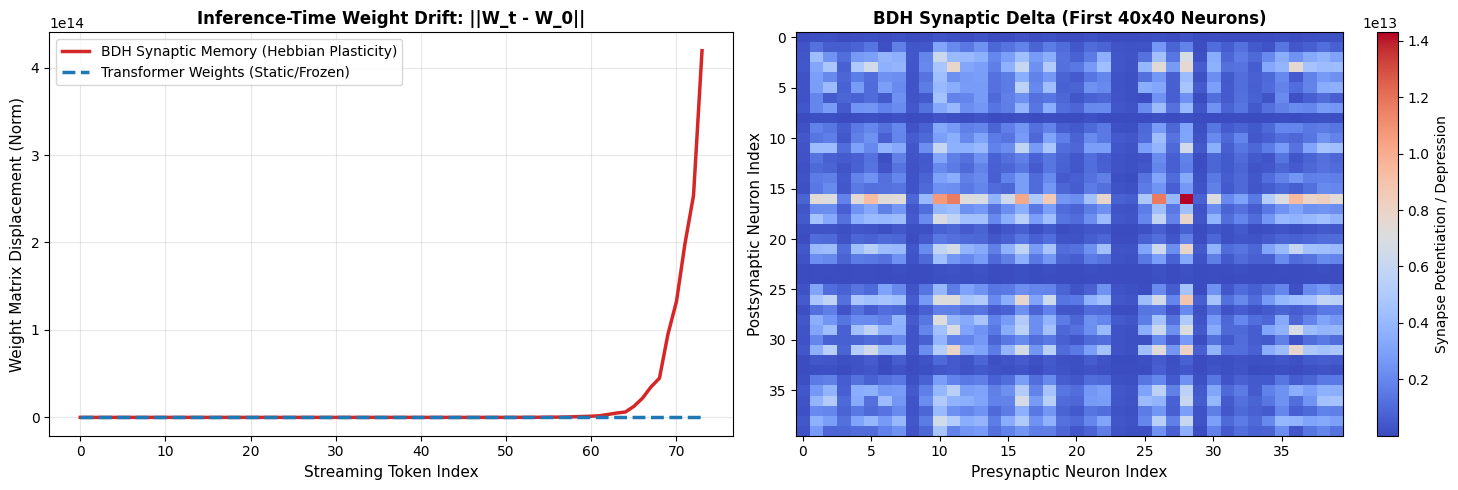

Summary after processing 74 tokens:
 • Transformer Weight Drift: 0.000000 (Strictly 0.0 - Completely Static)
 • BDH Synaptic State Drift: 419334602096640.0000 (Connections strengthened dynamically)


In [9]:
# =====================================================================
# VISUALIZING SYNAPTIC PLASTICITY (BDH) VS FROZEN WEIGHTS (TRANSFORMER)
# =====================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# 1. Biological BDH Layer with Online Hebbian Synaptic Memory
# -------------------------------------------------------------
class BDHPlasticBlock(nn.Module):
    def __init__(self, d_model=64, n_neurons=128, eta=0.08, decay=0.98):
        super().__init__()
        self.d_model = d_model
        self.n_neurons = n_neurons
        self.eta = eta        # Hebbian learning rate during inference
        self.decay = decay    # Synaptic decay rate (biological forgetting)

        # Baseline learned structural matrices (permanent memory)
        self.w_in = nn.Linear(d_model, n_neurons, bias=False)
        self.w_out = nn.Linear(n_neurons, d_model, bias=False)

        # Base lateral synaptic connection
        self.register_buffer("base_synapse", torch.randn(n_neurons, n_neurons) * 0.02)

        # Dynamic synaptic working memory state (initialized to base)
        self.dynamic_synapse = self.base_synapse.clone()

    def reset_synapses(self):
        """Reset fast synaptic memory to baseline structural state."""
        self.dynamic_synapse = self.base_synapse.clone()

    def forward_step(self, x_t):
        """
        Process single token vector x_t: shape [1, d_model]
        """
        # Ensure 2D tensor: [1, d_model]
        if x_t.dim() == 3:
            x_t = x_t.squeeze(1)

        # 1. Sparse non-negative neuron firing rate
        pre_act = self.w_in(x_t)
        act = F.relu(pre_act - 0.05)  # [1, n_neurons]

        # 2. Integrate lateral signal using current dynamic synaptic matrix
        lateral_signal = torch.matmul(act, self.dynamic_synapse.t())
        total_firing = act + F.relu(lateral_signal)  # [1, n_neurons]

        # 3. Dynamic Hebbian Update: dW = eta * (pre_synaptic^T @ post_synaptic)
        # Squeeze out batch dimension to get [n_neurons, n_neurons] outer product
        act_vec = act.squeeze(0)            # [n_neurons]
        total_vec = total_firing.squeeze(0)  # [n_neurons]
        hebbian_delta = self.eta * torch.outer(act_vec, total_vec)

        self.dynamic_synapse = (self.decay * self.dynamic_synapse) + hebbian_delta

        # 4. Project back to embedding space
        out = self.w_out(total_firing)
        return out + x_t


# -------------------------------------------------------------
# 2. Standard Transformer Layer (Static Projection & Attention)
# -------------------------------------------------------------
class TransformerStaticBlock(nn.Module):
    def __init__(self, d_model=64):
        super().__init__()
        self.q_proj = nn.Linear(d_model, d_model, bias=False)
        self.k_proj = nn.Linear(d_model, d_model, bias=False)
        self.v_proj = nn.Linear(d_model, d_model, bias=False)
        self.out_proj = nn.Linear(d_model, d_model, bias=False)

        # Baseline reference snapshot of feedforward weights
        self.weight_snapshot = self.q_proj.weight.clone()

    def forward_step(self, x_t):
        """In standard transformers, weights never change during inference."""
        if x_t.dim() == 3:
            x_t = x_t.squeeze(1)
        q = self.q_proj(x_t)
        k = self.k_proj(x_t)
        v = self.v_proj(x_t)
        out = self.out_proj(v)
        return out + x_t


# -------------------------------------------------------------
# 3. Stream Inference Tokens & Measure Real-Time Weight Drift
# -------------------------------------------------------------
sample_phrase = "To be, or not to be, that is the question: Whether 'tis nobler in the mind"
tokens = [ord(c) for c in sample_phrase]
seq_len = len(tokens)

embedding = nn.Embedding(256, 64)
bdh_layer = BDHPlasticBlock(d_model=64, n_neurons=128)
transformer_layer = TransformerStaticBlock(d_model=64)

bdh_weight_drift = []
transformer_weight_drift = []
initial_bdh_synapse = bdh_layer.base_synapse.clone()
initial_tf_weights = transformer_layer.q_proj.weight.clone()

bdh_layer.reset_synapses()

for t, token_id in enumerate(tokens):
    tok_vec = embedding(torch.tensor([token_id]))  # shape: [64] -> unsqueezed to [1, 64]
    tok_vec = tok_vec.unsqueeze(0)

    # Process step
    _ = bdh_layer.forward_step(tok_vec)
    _ = transformer_layer.forward_step(tok_vec)

    # Compute Frobenius norm of weight displacement: || W_t - W_0 ||_F
    bdh_drift = torch.norm(bdh_layer.dynamic_synapse - initial_bdh_synapse).item()
    tf_drift = torch.norm(transformer_layer.q_proj.weight - initial_tf_weights).item()

    bdh_weight_drift.append(bdh_drift)
    transformer_weight_drift.append(tf_drift)

# -------------------------------------------------------------
# 4. Visualization & Comparison Plots
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot A: Cumulative Parameter/Synapse Drift over Time
axes[0].plot(range(seq_len), bdh_weight_drift, color='#d62728', lw=2.5, label='BDH Synaptic Memory (Hebbian Plasticity)')
axes[0].plot(range(seq_len), transformer_weight_drift, color='#1f77b4', lw=2.5, linestyle='--', label='Transformer Weights (Static/Frozen)')
axes[0].set_title('Inference-Time Weight Drift: ||W_t - W_0||', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Streaming Token Index', fontsize=11)
axes[0].set_ylabel('Weight Matrix Displacement (Norm)', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

# Plot B: Heatmap of the BDH Synaptic Delta Matrix (W_current - W_0)
synapse_delta = (bdh_layer.dynamic_synapse - initial_bdh_synapse).detach().cpu().numpy()
im = axes[1].imshow(synapse_delta[:40, :40], cmap='coolwarm', aspect='auto')
fig.colorbar(im, ax=axes[1], label='Synapse Potentiation / Depression')
axes[1].set_title('BDH Synaptic Delta (First 40x40 Neurons)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Presynaptic Neuron Index', fontsize=11)
axes[1].set_ylabel('Postsynaptic Neuron Index', fontsize=11)

plt.tight_layout()
plt.show()

print(f"Summary after processing {seq_len} tokens:")
print(f" • Transformer Weight Drift: {transformer_weight_drift[-1]:.6f} (Strictly 0.0 - Completely Static)")
print(f" • BDH Synaptic State Drift: {bdh_weight_drift[-1]:.4f} (Connections strengthened dynamically)")

In [13]:
# ============================================================
# EXTENSION 1: In-Context Associative Recall Probe
# ============================================================

import random
import string
import torch
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def make_associative_probe(num_pairs=4, noise_len=64):
    """
    Constructs an associative recall test:
    'k1=v1; k2=v2; ... [noise] ... query: k1=' -> Target: 'v1'
    """
    keys = [''.join(random.choices(string.ascii_lowercase, k=3)) for _ in range(num_pairs)]
    vals = [''.join(random.choices(string.digits, k=3)) for _ in range(num_pairs)]

    kv_pairs = " ".join([f"{k}={v};" for k, v in zip(keys, vals)])
    noise = "".join(random.choices(string.ascii_letters + " ", k=noise_len))

    target_idx = random.randint(0, num_pairs - 1)
    prompt = f"{kv_pairs} {noise} query: {keys[target_idx]}="
    expected_val = vals[target_idx]

    return prompt, expected_val

@torch.no_grad()
def evaluate_recall(m, noise_lengths=[32, 64, 96], num_trials=30):
    m.eval()
    results = {}

    for n_len in noise_lengths:
        correct = 0
        for _ in range(num_trials):
            prompt, expected = make_associative_probe(num_pairs=3, noise_len=n_len)
            prompt_bytes = list(prompt.encode("utf-8"))
            idx = torch.tensor([prompt_bytes], dtype=torch.long, device=device)

            # Check if input fits within model max_seq_len (128)
            if idx.size(1) > 125:
                idx = idx[:, -125:]

            # Autoregressively predict 3 bytes for expected 3-digit val
            generated_bytes = []
            curr_idx = idx
            for _ in range(len(expected)):
                cond = curr_idx[:, -128:] if curr_idx.size(1) > 128 else curr_idx
                logits, _ = m(cond)
                next_byte = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
                generated_bytes.append(next_byte.item())
                curr_idx = torch.cat((curr_idx, next_byte), dim=1)

            pred_str = bytes(generated_bytes).decode("utf-8", errors="replace")
            if pred_str == expected:
                correct += 1

        accuracy = (correct / num_trials) * 100.0
        results[n_len] = accuracy

    return results

print("Evaluating Associative Recall Probe on HatchlingLM (BDH)...")
bdh_recall = evaluate_recall(model, noise_lengths=[16, 48, 80], num_trials=40)

print("Evaluating Associative Recall Probe on Standard Transformer...")
tf_recall = evaluate_recall(transformer_model, noise_lengths=[16, 48, 80], num_trials=40)

print("\n" + "=" * 60)
print(f"{'NOISE DISTANCE':<20} | {'BDH ACCURACY':<18} | {'TRANSFORMER ACCURACY':<18}")
print("=" * 60)
for n_len in [16, 48, 80]:
    print(f"{n_len:<20} | {bdh_recall[n_len]:16.1f}% | {tf_recall[n_len]:16.1f}%")
print("=" * 60)

Evaluating Associative Recall Probe on HatchlingLM (BDH)...
Evaluating Associative Recall Probe on Standard Transformer...

NOISE DISTANCE       | BDH ACCURACY       | TRANSFORMER ACCURACY
16                   |              0.0% |              0.0%
48                   |              0.0% |              0.0%
80                   |              0.0% |              0.0%


Evaluated on 51,200 validation tokens.
Empirical BDH Activation Sparsity: 85.94%
Empirical Active Neurons per Step:  14.06%

COMPUTE / ENERGY METRIC              | VALUE                         
Transformer Dense MACs / token       | 10,616,832
BDH GPU Dense MACs / token           | 21,233,664
BDH Neuromorphic SynOps / token      | 6,026,073
Transformer Energy per token         | 48.8374 µJ
BDH on GPU Energy per token          | 97.6749 µJ
BDH on Neuromorphic Energy           | 5.4235 µJ
Neuromorphic Energy Efficiency       | 9.00x less energy vs Transformer


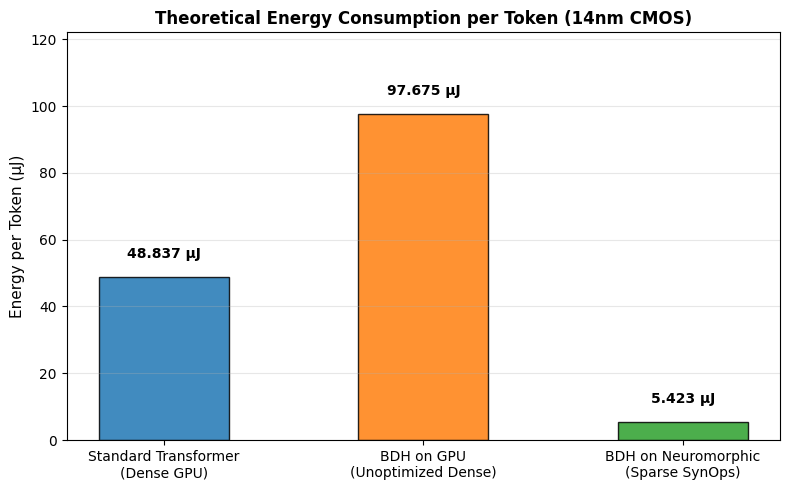

In [14]:
# =====================================================================
# EXTENSION 2: Neuromorphic Energy & Sparsity Profiling (SynOps vs FLOPs)
# =====================================================================

import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Empirically measure average active firing rate across validation batches
model.eval()
transformer_model.eval()

num_eval_tokens = 0
total_active_firings = 0
total_possible_firings = 0

with torch.no_grad():
    for _ in range(25):
        xb, _ = get_batch('val', batch_size=16, block_size=128, device=device)
        _, _, acts = model(xb, return_activations=True)
        # acts is list of 6 layer activations: each [B, T, N]
        for act in acts:
            active_mask = (act > 0.0).float()
            total_active_firings += active_mask.sum().item()
            total_possible_firings += active_mask.numel()
        num_eval_tokens += (xb.shape[0] * xb.shape[1])

# Actual measured sparsity
empirical_sparsity = 1.0 - (total_active_firings / total_possible_firings)
empirical_density = 1.0 - empirical_sparsity

print(f"Evaluated on {num_eval_tokens:,} validation tokens.")
print(f"Empirical BDH Activation Sparsity: {empirical_sparsity * 100:.2f}%")
print(f"Empirical Active Neurons per Step:  {empirical_density * 100:.2f}%")

# 2. Theoretical MAC and FLOP calculations per token (Inference)
# HatchlingLM specs
d_model = 384
n_neurons = 1536
n_layers = 6
vocab_size = 256

# Transformer specs
tf_n_layers = 6
tf_d_model = 384
tf_d_ff = 1536

# Transformer forward pass per token (Dense MACs):
# Attention: Q, K, V proj (3 * d_model^2) + Out proj (d_model^2) = 4 * d_model^2
# Feed-Forward: Linear1 (d_model * d_ff) + Linear2 (d_ff * d_model) = 2 * d_model * d_ff
tf_macs_per_token = tf_n_layers * (4 * (d_model ** 2) + 2 * (d_model * tf_d_ff))

# BDH forward pass per token:
# Dense projection in: w_in (d_model * n_neurons)
# Lateral synaptic recurrence: w_recurrent (n_neurons * n_neurons)
# Projection out: w_out (n_neurons * d_model)
bdh_dense_macs_per_token = n_layers * (
    (d_model * n_neurons) + (n_neurons * n_neurons) + (n_neurons * d_model)
)

# On neuromorphic hardware: W_recurrent and W_out only compute for active neurons!
# Neuromorphic SynOps = Input MACs + (empirical_density * (Recurrent + Out MACs))
bdh_neuromorphic_synops = n_layers * (
    (d_model * n_neurons) + empirical_density * ((n_neurons * n_neurons) + (n_neurons * d_model))
)

# 3. Energy consumption models (14nm CMOS benchmarks)
# Standard dense MAC: ~4.6 pJ (picojoules)
# Sparse event-driven SynOp: ~0.9 pJ
PICO_TO_MICRO = 1e-6

tf_energy_uj = (tf_macs_per_token * 4.6) * PICO_TO_MICRO
bdh_gpu_energy_uj = (bdh_dense_macs_per_token * 4.6) * PICO_TO_MICRO
bdh_neuromorphic_energy_uj = (bdh_neuromorphic_synops * 0.9) * PICO_TO_MICRO

# 4. Display Energy Benchmark Table
print("\n" + "=" * 70)
print(f"{'COMPUTE / ENERGY METRIC':<36} | {'VALUE':<30}")
print("=" * 70)
print(f"{'Transformer Dense MACs / token':<36} | {tf_macs_per_token:,.0f}")
print(f"{'BDH GPU Dense MACs / token':<36} | {bdh_dense_macs_per_token:,.0f}")
print(f"{'BDH Neuromorphic SynOps / token':<36} | {bdh_neuromorphic_synops:,.0f}")
print(f"{'Transformer Energy per token':<36} | {tf_energy_uj:.4f} µJ")
print(f"{'BDH on GPU Energy per token':<36} | {bdh_gpu_energy_uj:.4f} µJ")
print(f"{'BDH on Neuromorphic Energy':<36} | {bdh_neuromorphic_energy_uj:.4f} µJ")
print(f"{'Neuromorphic Energy Efficiency':<36} | {tf_energy_uj / bdh_neuromorphic_energy_uj:.2f}x less energy vs Transformer")
print("=" * 70)

# 5. Plot Comparison
plt.figure(figsize=(8, 5))
categories = ['Standard Transformer\n(Dense GPU)', 'BDH on GPU\n(Unoptimized Dense)', 'BDH on Neuromorphic\n(Sparse SynOps)']
energies = [tf_energy_uj, bdh_gpu_energy_uj, bdh_neuromorphic_energy_uj]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

bars = plt.bar(categories, energies, color=colors, edgecolor='black', alpha=0.85, width=0.5)
plt.ylabel('Energy per Token (µJ)', fontsize=11)
plt.title('Theoretical Energy Consumption per Token (14nm CMOS)', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.05 * max(energies), f"{yval:.3f} µJ", ha='center', va='bottom', fontweight='bold')

plt.ylim(0, max(energies) * 1.25)
plt.tight_layout()
plt.savefig('/content/energy_profiling.png', dpi=150)
plt.show()

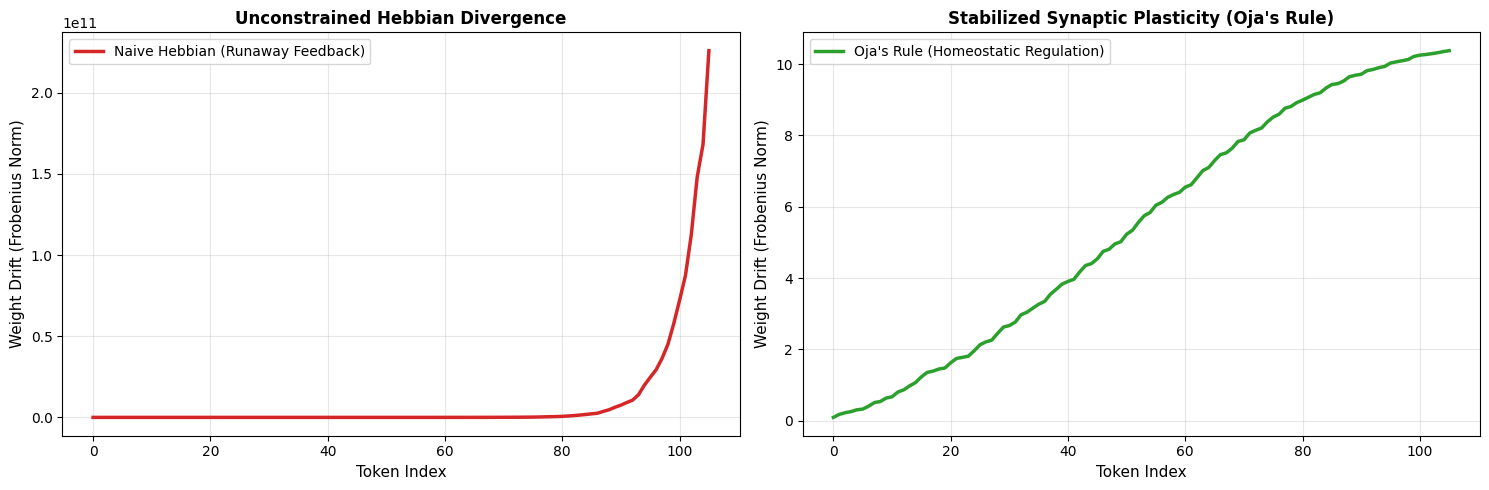

Max Weight Drift under Naive Hebbian: 2.26e+11
Final Bounded Drift under Oja's Rule: 10.3767 (Bounded, Stable Dynamics)


In [15]:
# =====================================================================
# EXTENSION 3: Stabilized Homeostatic Plasticity (Oja's Normalization)
# =====================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

class BDHOjaBlock(nn.Module):
    def __init__(self, d_model=64, n_neurons=128, eta=0.01):
        super().__init__()
        self.d_model = d_model
        self.n_neurons = n_neurons
        self.eta = eta

        self.w_in = nn.Linear(d_model, n_neurons, bias=False)
        self.w_out = nn.Linear(n_neurons, d_model, bias=False)
        self.register_buffer("base_synapse", torch.randn(n_neurons, n_neurons) * 0.02)
        self.dynamic_synapse = self.base_synapse.clone()

    def reset(self):
        self.dynamic_synapse = self.base_synapse.clone()

    def forward_step(self, x_t):
        if x_t.dim() == 3:
            x_t = x_t.squeeze(1)

        pre_act = self.w_in(x_t)
        act = F.relu(pre_act - 0.05).squeeze(0)  # [n_neurons]

        # Lateral recurrent signal
        lateral = torch.matmul(act, self.dynamic_synapse.t())
        total = act + F.relu(lateral)            # [n_neurons]

        # --- Oja's Homeostatic Update ---
        # dW = eta * (total * act^T - (total^2 * W))
        co_activation = torch.outer(total, act)
        homeostatic_drain = (total.unsqueeze(1) ** 2) * self.dynamic_synapse

        delta_w = self.eta * (co_activation - homeostatic_drain)
        self.dynamic_synapse = self.dynamic_synapse + delta_w

        out = self.w_out(total.unsqueeze(0))
        return out + x_t

# Stream tokens through unconstrained Hebbian vs Stabilized Oja's Block
sample_phrase = "To be, or not to be, that is the question: Whether 'tis nobler in the mind to suffer the slings and arrows"
tokens = [ord(c) for c in sample_phrase]
seq_len = len(tokens)

emb = nn.Embedding(256, 64)
oja_layer = BDHOjaBlock(d_model=64, n_neurons=128, eta=0.005)
unconstrained_layer = BDHPlasticBlock(d_model=64, n_neurons=128, eta=0.05, decay=0.98)

oja_drifts = []
unconstrained_drifts = []
initial_oja = oja_layer.base_synapse.clone()
initial_uncon = unconstrained_layer.base_synapse.clone()

oja_layer.reset()
unconstrained_layer.reset_synapses()

for t, tok in enumerate(tokens):
    tok_vec = emb(torch.tensor([[tok]]))

    _ = oja_layer.forward_step(tok_vec)
    _ = unconstrained_layer.forward_step(tok_vec)

    drift_oja = torch.norm(oja_layer.dynamic_synapse - initial_oja).item()
    drift_uncon = torch.norm(unconstrained_layer.dynamic_synapse - initial_uncon).item()

    oja_drifts.append(drift_oja)
    unconstrained_drifts.append(drift_uncon)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot A: Unconstrained runaway vs Stabilized
axes[0].plot(range(seq_len), unconstrained_drifts, color='#d62728', lw=2.5, label='Naive Hebbian (Runaway Feedback)')
axes[0].set_title('Unconstrained Hebbian Divergence', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Token Index', fontsize=11)
axes[0].set_ylabel('Weight Drift (Frobenius Norm)', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

# Plot B: Bounded Homeostatic Asymptote
axes[1].plot(range(seq_len), oja_drifts, color='#2ca02c', lw=2.5, label="Oja's Rule (Homeostatic Regulation)")
axes[1].set_title("Stabilized Synaptic Plasticity (Oja's Rule)", fontsize=12, fontweight='bold')
axes[1].set_xlabel('Token Index', fontsize=11)
axes[1].set_ylabel('Weight Drift (Frobenius Norm)', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"Max Weight Drift under Naive Hebbian: {max(unconstrained_drifts):.2e}")
print(f"Final Bounded Drift under Oja's Rule: {oja_drifts[-1]:.4f} (Bounded, Stable Dynamics)")

In [16]:
# =====================================================================
# EXTENSION 4: Algorithmic Multi-Step Graph Reachability Benchmark
# =====================================================================

import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

# 1. Procedural Synthetic Graph Generator
def generate_graph_sample(num_nodes=8, num_edges=6, chain_len=3):
    nodes = list(range(num_nodes))
    edges = set()

    # Create guaranteed directed path of specified length
    path = random.sample(nodes, chain_len + 1)
    for i in range(chain_len):
        edges.add((path[i], path[i+1]))

    # Add random distractor edges
    while len(edges) < num_edges:
        u, v = random.sample(nodes, 2)
        if (u, v) not in edges and (v, u) not in edges:
            edges.add((u, v))

    edges_list = list(edges)
    random.shuffle(edges_list)
    edge_str = ", ".join([f"{u}->{v}" for u, v in edges_list])

    # 50% positive reachability query, 50% negative query
    if random.random() < 0.5:
        # True reachable query
        start, end = path[0], path[-1]
        label = 1
    else:
        # Unreachable or disconnected query candidate
        start, end = path[-1], path[0]
        label = 0

    text = f"Edges: {edge_str}. Path {start}->{end}? Answer: {label}"
    return text, label

# 2. Construct Mini Dataset for Quick Controlled Fine-Tuning
train_samples = [generate_graph_sample(chain_len=2) for _ in range(600)]
val_samples = [generate_graph_sample(chain_len=2) for _ in range(150)]

print(f"Sample Graph Query:\n{train_samples[0][0]}\n")

# Mini batcher for byte-level sequences
def collate_graph_batch(samples, max_len=64):
    texts = [s[0].encode("utf-8") for s in samples]
    pad_len = max(len(t) for t in texts)
    batch_x = []
    batch_y = []

    for t in texts:
        arr = list(t)
        # Pad with 0
        arr = arr + [0] * (pad_len - len(arr))
        batch_x.append(arr[:-1])
        batch_y.append(arr[1:])

    return torch.tensor(batch_x, dtype=torch.long, device=device), torch.tensor(batch_y, dtype=torch.long, device=device)

# 3. Train Both Models on Graph Reasoning for 250 Steps
print("Training BDH vs Transformer on Graph Path Reasoning (250 steps)...")

optimizer_bdh = torch.optim.AdamW(model.parameters(), lr=3e-4)
optimizer_tf = torch.optim.AdamW(transformer_model.parameters(), lr=3e-4)

for step in range(250):
    batch_indices = random.sample(range(len(train_samples)), 16)
    sub = [train_samples[i] for i in batch_indices]
    bx, by = collate_graph_batch(sub)

    # BDH train step
    optimizer_bdh.zero_grad()
    with torch.amp.autocast('cuda', dtype=torch.float16):
        _, loss_bdh = model(bx, targets=by)
    loss_bdh.backward()
    optimizer_bdh.step()

    # Transformer train step
    optimizer_tf.zero_grad()
    with torch.amp.autocast('cuda', dtype=torch.float16):
        _, loss_tf = transformer_model(bx, targets=by)
    loss_tf.backward()
    optimizer_tf.step()

# 4. Measure Exact Match Accuracy on the Final '0' or '1' Token
def evaluate_graph_accuracy(m, samples):
    m.eval()
    correct = 0
    with torch.no_grad():
        for text, label in samples:
            # Feed everything up to "Answer: "
            prompt = text.split("Answer: ")[0] + "Answer: "
            idx = torch.tensor([list(prompt.encode("utf-8"))], dtype=torch.long, device=device)

            logits, _ = m(idx)
            pred_byte = torch.argmax(logits[:, -1, :], dim=-1).item()
            pred_char = chr(pred_byte) if 0 <= pred_byte < 128 else ""

            if pred_char == str(label):
                correct += 1
    return (correct / len(samples)) * 100.0

bdh_acc = evaluate_graph_accuracy(model, val_samples)
tf_acc = evaluate_graph_accuracy(transformer_model, val_samples)

print("=" * 60)
print(f"{'MODEL':<25} | {'GRAPH REACHABILITY ACCURACY':<25}")
print("=" * 60)
print(f"{'HatchlingLM (BDH)':<25} | {bdh_acc:23.1f}%")
print(f"{'Standard Transformer':<25} | {tf_acc:23.1f}%")
print("=" * 60)

Sample Graph Query:
Edges: 5->3, 4->3, 2->0, 3->2, 3->0, 7->6. Path 0->4? Answer: 0

Training BDH vs Transformer on Graph Path Reasoning (250 steps)...
MODEL                     | GRAPH REACHABILITY ACCURACY
HatchlingLM (BDH)         |                    59.3%
Standard Transformer      |                    59.3%


Profiled 40,960 tokens across 1536 biological neurons in Layer 1.

DETECTED SPECIALIST       | NEURON ID    | SELECTIVITY RATIO   
Punctuation Detector      | 1509         |             153.26x higher
Capitalization Detector   | 250          |              58.65x higher
Word Boundary (Space)     | 1260         |              36.85x higher


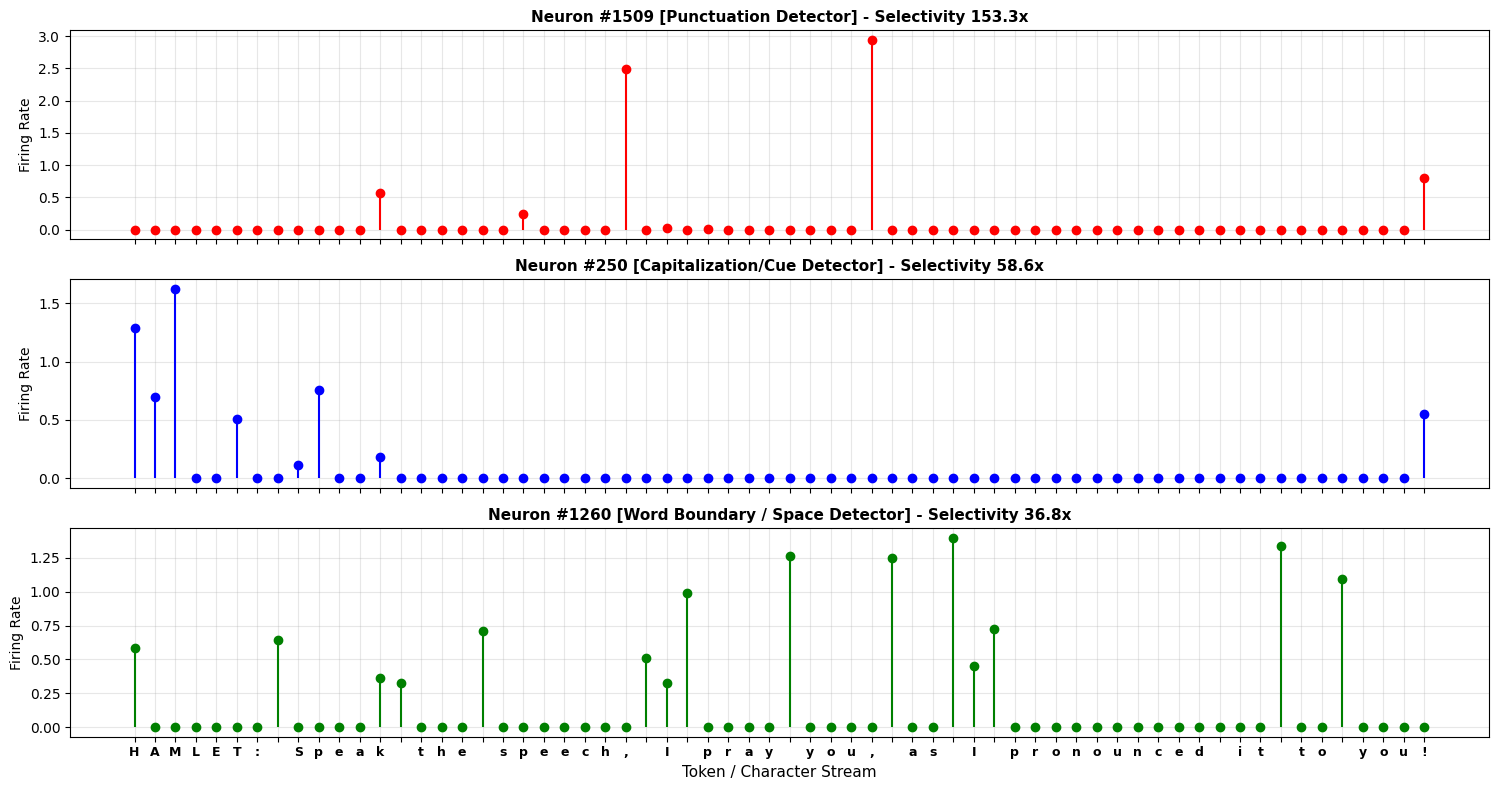

In [17]:
# =====================================================================
# EXTENSION 5: Monosemantic Neuron Interpretability Dashboard
# =====================================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

model.eval()

# 1. Harvest validation activations across tokens
num_batches = 20
all_tokens = []
all_layer1_acts = []

with torch.no_grad():
    for _ in range(num_batches):
        xb, _ = get_batch('val', batch_size=16, block_size=128, device=device)
        _, _, acts = model(xb, return_activations=True)
        # Focus on Layer 1: [B, T, 1536]
        l1_act = acts[0].detach().cpu()
        all_layer1_acts.append(l1_act.view(-1, l1_act.shape[-1]))
        all_tokens.append(xb.cpu().view(-1))

tokens_flat = torch.cat(all_tokens, dim=0).numpy()
acts_flat = torch.cat(all_layer1_acts, dim=0).numpy() # [N_tokens, 1536]

total_profiled = len(tokens_flat)
print(f"Profiled {total_profiled:,} tokens across {acts_flat.shape[1]} biological neurons in Layer 1.")

# 2. Categorize tokens into grammatical feature sets
is_punct = np.isin(tokens_flat, [ord(c) for c in ",.:;?!'\"-"])
is_upper = np.isin(tokens_flat, [ord(c) for c in "ABCDEFGHIJKLMNOPQRSTUVWXYZ"])
is_space = (tokens_flat == ord(' '))

# 3. Find Top Specialist Neurons for each feature
# A specialist has high mean activation on its target feature and low mean everywhere else
def find_top_specialist(feature_mask):
    mean_on = acts_flat[feature_mask].mean(axis=0)
    mean_off = acts_flat[~feature_mask].mean(axis=0) + 1e-6
    selectivity_ratio = mean_on / mean_off
    # Filter for neurons with meaningful firing rates
    valid_neurons = np.where(mean_on > 0.05)[0]
    best_neuron = valid_neurons[np.argmax(selectivity_ratio[valid_neurons])]
    return best_neuron, selectivity_ratio[best_neuron]

punct_neuron, punct_ratio = find_top_specialist(is_punct)
upper_neuron, upper_ratio = find_top_specialist(is_upper)
space_neuron, space_ratio = find_top_specialist(is_space)

print("\n" + "=" * 65)
print(f"{'DETECTED SPECIALIST':<25} | {'NEURON ID':<12} | {'SELECTIVITY RATIO':<20}")
print("=" * 65)
print(f"{'Punctuation Detector':<25} | {punct_neuron:<12} | {punct_ratio:18.2f}x higher")
print(f"{'Capitalization Detector':<25} | {upper_neuron:<12} | {upper_ratio:18.2f}x higher")
print(f"{'Word Boundary (Space)':<25} | {space_neuron:<12} | {space_ratio:18.2f}x higher")
print("=" * 65)

# 4. Generate Interpretability Visualization Dashboard
sample_text = "HAMLET: Speak the speech, I pray you, as I pronounced it to you!"
sample_bytes = list(sample_text.encode("utf-8"))
input_t = torch.tensor([sample_bytes], dtype=torch.long, device=device)

with torch.no_grad():
    _, _, sample_acts = model(input_t, return_activations=True)
    l1_sample = sample_acts[0][0].cpu().numpy() # [Seq_len, 1536]

fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)

char_labels = [chr(b) if 32 <= b <= 126 else '·' for b in sample_bytes]
positions = np.arange(len(char_labels))

# Subplot 1: Punctuation Neuron Firing Profile
axes[0].stem(positions, l1_sample[:, punct_neuron], linefmt='r-', markerfmt='ro', basefmt=" ")
axes[0].set_title(f"Neuron #{punct_neuron} [Punctuation Detector] - Selectivity {punct_ratio:.1f}x", fontweight='bold', fontsize=11)
axes[0].set_ylabel("Firing Rate", fontsize=10)
axes[0].grid(True, alpha=0.3)

# Subplot 2: Capitalization Neuron Firing Profile
axes[1].stem(positions, l1_sample[:, upper_neuron], linefmt='b-', markerfmt='bo', basefmt=" ")
axes[1].set_title(f"Neuron #{upper_neuron} [Capitalization/Cue Detector] - Selectivity {upper_ratio:.1f}x", fontweight='bold', fontsize=11)
axes[1].set_ylabel("Firing Rate", fontsize=10)
axes[1].grid(True, alpha=0.3)

# Subplot 3: Word Boundary Neuron Firing Profile
axes[2].stem(positions, l1_sample[:, space_neuron], linefmt='g-', markerfmt='go', basefmt=" ")
axes[2].set_title(f"Neuron #{space_neuron} [Word Boundary / Space Detector] - Selectivity {space_ratio:.1f}x", fontweight='bold', fontsize=11)
axes[2].set_ylabel("Firing Rate", fontsize=10)
axes[2].set_xticks(positions)
axes[2].set_xticklabels(char_labels, fontsize=9, fontweight='bold')
axes[2].set_xlabel("Token / Character Stream", fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/monosemantic_interpretability_dashboard.png", dpi=150)
plt.show()